# Lab 2 — Saigon Bean: data types, data quality, descriptive statistics and dissimilarity

## Student: Huynh Tan Phat
## ID: K234131613

## Setup — imports and data location

In [1]:
import os, statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats as st
from scipy.spatial.distance import pdist, squareform

FILES = ["saigon_bean_stores.csv", "saigon_bean_products.csv", "saigon_bean_transactions.csv"]
DATA_URL = ""  
CANDIDATE_DIRS = ["data", ".", "/content/data", "/content",
                  "/content/drive/MyDrive/data", "/content/drive/MyDrive"]

def locate(fname):
    for d in CANDIDATE_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return (DATA_URL + fname) if DATA_URL else None

paths = {f: locate(f) for f in FILES}
missing = [f for f, p in paths.items() if p is None]
if missing:
    try:
        from google.colab import files          
        print("Please upload:", missing)
        files.upload()                           
        paths = {f: locate(f) for f in FILES}
    except ImportError:
        pass
still = [f for f, p in paths.items() if p is None]
if still:
    raise FileNotFoundError(f"Data files not found: {still}. Put them in ./data or set DATA_URL.")

money = FuncFormatter(lambda v, _: f"{v/1000:,.0f}k")   # axis formatter: 45000 -> 45k
print("Data files found:", paths)

Data files found: {'saigon_bean_stores.csv': 'data\\saigon_bean_stores.csv', 'saigon_bean_products.csv': 'data\\saigon_bean_products.csv', 'saigon_bean_transactions.csv': 'data\\saigon_bean_transactions.csv'}


## Task 1 — Load the three files, join transactions to stores and to products, report the shape

In [2]:
stores   = pd.read_csv(paths["saigon_bean_stores.csv"])
products = pd.read_csv(paths["saigon_bean_products.csv"])
tx       = pd.read_csv(paths["saigon_bean_transactions.csv"])

print("stores      :", stores.shape)
print("products    :", products.shape)
print("transactions:", tx.shape)

# many transactions -> one store, many transactions -> one product; validate= makes pandas prove it
df = (tx.merge(stores,   on="store_id",   how="left", validate="m:1")
        .merge(products, on="product_id", how="left", validate="m:1"))

print("\nShape of the joined table:", df.shape)
print("Rows kept from transactions:", len(df) == len(tx))
print("Unmatched store keys  :", df["store_name"].isna().sum())
print("Unmatched product keys:", df["product_name"].isna().sum())
df.head()

stores      : (12, 5)
products    : (17, 4)
transactions: (97239, 10)

Shape of the joined table: (97239, 17)
Rows kept from transactions: True
Unmatched store keys  : 0
Unmatched product keys: 0


,order_id,store_id,order_time,channel,customer_id,product_id,quantity,unit_price,discount,line_total,store_name,district,store_type,seats,product_name,category,list_price
0,519273,4,6/1/2026 7:00,delivery,NaN,101,1,45000,0.0,45000,Vincom Dong Khoi,District 1,mall,54,Vietnamese Iced Milk Coffee,coffee,45000
1,519273,4,6/1/2026 7:00,delivery,NaN,301,1,31500,0.0,31500,Vincom Dong Khoi,District 1,mall,54,Butter Croissant,pastry,31500
2,524107,5,6/1/2026 7:06,in-store,12417.0,103,1,52000,0.0,52000,Crescent Mall,District 7,mall,48,Latte,coffee,52000
3,500071,1,6/1/2026 7:07,in-store,NaN,201,2,45000,0.0,90000,Nguyen Hue,District 1,mall,70,Peach Tea,tea,45000
4,500071,1,6/1/2026 7:07,in-store,NaN,202,2,42000,0.0,84000,Nguyen Hue,District 1,mall,70,Lotus Tea,tea,42000


## Task 2a — Attribute-type table for all columns

In [3]:
attr = pd.DataFrame([
    ("order_id",     "Nominal (identifier)"),
    ("store_id",     "Nominal (identifier)"),
    ("order_time",   "Interval (date-time)"),
    ("channel",      "Nominal"),
    ("customer_id",  "Nominal (identifier)"),
    ("product_id",   "Nominal (identifier)"),
    ("quantity",     "Ratio (discrete)"),
    ("unit_price",   "Ratio (continuous)"),
    ("discount",     "Ratio (continuous)"),
    ("line_total",   "Ratio (continuous)"),
    ("store_name",   "Nominal"),
    ("district",     "Nominal"),
    ("store_type",   "Nominal"),
    ("seats",        "Ratio (discrete)"),
    ("product_name", "Nominal"),
    ("category",     "Nominal"),
    ("list_price",   "Ratio (continuous)"),
], columns=["column", "attribute_type"])

# every column of the joined table must be classified, none twice
assert set(attr["column"]) == set(df.columns) and attr["column"].is_unique

attr.insert(1, "pandas_dtype", [str(df[c].dtype) for c in attr["column"]])
attr["n_unique"] = [df[c].nunique() for c in attr["column"]]
attr["n_missing"] = [int(df[c].isna().sum()) for c in attr["column"]]
display(attr)

,column,pandas_dtype,attribute_type,n_unique,n_missing
0,order_id,int64,Nominal (identifier),51108,0
1,store_id,int64,Nominal (identifier),12,0
2,order_time,object,Interval (date-time),36678,0
3,channel,object,Nominal,6,0
4,customer_id,float64,Nominal (identifier),4777,33569
5,product_id,int64,Nominal (identifier),17,0
6,quantity,int64,Ratio (discrete),4,0
7,unit_price,int64,Ratio (continuous),14,0
8,discount,float64,Ratio (continuous),4,0
9,line_total,int64,Ratio (continuous),96,0


## Task 2b — Find the five faults

In [4]:
neg_qty   = df["quantity"] < 0
bad_price = df["unit_price"] > df["list_price"] * 10

print("Fault 1  duplicated rows                :", df.duplicated().sum())
print("Fault 2  channel labels                 :", df["channel"].value_counts().to_dict())
print("Fault 3  negative quantity              :", neg_qty.sum())
print("Fault 4  unit_price > 10 x list_price   :", bad_price.sum(),
      "| ratio unit/list of these rows:", sorted((df.loc[bad_price, "unit_price"] / df.loc[bad_price, "list_price"]).unique()))
print("Fault 5  customer_id missing            :", df["customer_id"].isna().sum(),
      f"({df['customer_id'].isna().mean():.1%} of rows)")
print("(type issue) order_time dtype           :", df["order_time"].dtype)

# evidence for fault 3: are the negative rows refunds that have a positive twin, or plain sign errors?
key = ["order_id", "product_id"]
twins = df.loc[neg_qty, key].merge(df.loc[~neg_qty, key].drop_duplicates(), on=key, how="inner")
print("\nNegative-quantity rows with a positive twin (same order and product):", len(twins))
print("Negative rows also have negative line_total:", (df.loc[neg_qty, "line_total"] < 0).all())

Fault 1  duplicated rows                : 40
Fault 2  channel labels                 : {'in-store': 60939, 'app': 23057, 'delivery': 13213, 'In-Store': 19, 'Delivery': 6, 'App': 5}
Fault 3  negative quantity              : 25
Fault 4  unit_price > 10 x list_price   : 12 | ratio unit/list of these rows: [np.float64(100.0)]
Fault 5  customer_id missing            : 33569 (34.5% of rows)
(type issue) order_time dtype           : object

Negative-quantity rows with a positive twin (same order and product): 0
Negative rows also have negative line_total: True


## Task 2c — Repair the faults (keep the missing `customer_id` rows and add a flag)

| # | Fault | Repair |
|---|-------|--------|
| 1 | Exact duplicate rows | drop duplicates |
| 2 | Channel labels in mixed case (`In-Store`, `Delivery`, `App`) | strip and lower-case to three labels |
| 3 | Negative `quantity` (no positive twin, so a sign error, not a refund) | take the absolute value |
| 4 | `unit_price` 100 times too large | reset to `list_price` |
| 5 | Missing `customer_id` | **keep the rows**, add boolean flag `customer_id_missing` |

`line_total` is recomputed only for rows touched by faults 3 and 4. `order_time` is also converted from text to datetime, which is needed for the hour analysis.

In [5]:
clean = df.copy()

# 1 duplicates
clean = clean.drop_duplicates().copy()

# 2 channel labels
clean["channel"] = clean["channel"].str.strip().str.lower()

# 3 negative quantity -> sign error
neg = clean["quantity"] < 0
clean.loc[neg, "quantity"] = clean.loc[neg, "quantity"].abs()

# 4 price-scale error -> back to list price
bad = clean["unit_price"] > clean["list_price"] * 10
clean.loc[bad, "unit_price"] = clean.loc[bad, "list_price"]

# line_total only where quantity or unit_price was repaired
fixed = neg | bad
clean.loc[fixed, "line_total"] = (clean.loc[fixed, "quantity"] * clean.loc[fixed, "unit_price"]
                                  * (1 - clean.loc[fixed, "discount"])).round().astype("int64")

# 5 missing customer_id: keep rows, add flag (nullable integer keeps the ids as whole numbers)
clean["customer_id_missing"] = clean["customer_id"].isna()
clean["customer_id"] = clean["customer_id"].astype("Int64")

# type fix
clean["order_time"] = pd.to_datetime(clean["order_time"], format="%m/%d/%Y %H:%M")


before = len(clean)
clean = clean.drop_duplicates().copy()
print("Extra duplicates created by the repairs:", before - len(clean))

print("Rows before / after:", len(df), "/", len(clean))
print("Rows with quantity repaired:", int(neg.sum()), "| rows with price repaired:", int(bad.sum()))

Extra duplicates created by the repairs: 0
Rows before / after: 97239 / 97199
Rows with quantity repaired: 25 | rows with price repaired: 12


## Task 2d — Verify the repairs

In [6]:
recalc = (clean["quantity"] * clean["unit_price"] * (1 - clean["discount"])).round()

checks = {
    "no duplicated rows":              clean.duplicated().sum() == 0,
    "three channel labels only":       set(clean["channel"].unique()) == {"in-store", "app", "delivery"},
    "quantity always positive":        bool((clean["quantity"] > 0).all()),
    "no unit_price > 10 x list_price": not (clean["unit_price"] > clean["list_price"] * 10).any(),
    "missing customer_id kept+flagged": clean["customer_id_missing"].sum() == clean["customer_id"].isna().sum(),
    "order_time is datetime":          pd.api.types.is_datetime64_any_dtype(clean["order_time"]),
}
for name, ok in checks.items():
    print("PASS" if ok else "FAIL", "-", name)
print()
print("Shape after repair      :", clean.shape)
print("Duplicated rows         :", clean.duplicated().sum())
print("Channel counts          :", clean["channel"].value_counts().to_dict())
print("quantity values         :", sorted(clean["quantity"].unique()))
print("max unit_price/list     :", (clean["unit_price"] / clean["list_price"]).max())
print("customer_id_missing     :", int(clean["customer_id_missing"].sum()), "rows kept and flagged")
print("line_total min / max    :", clean["line_total"].min(), "/", clean["line_total"].max())
print("line_total != quantity*unit_price*(1-discount) by more than 1 dong:",
      int(((recalc - clean["line_total"]).abs() > 1).sum()), "rows")
print("order_time range        :", clean["order_time"].min(), "->", clean["order_time"].max())

PASS - no duplicated rows
PASS - three channel labels only
PASS - quantity always positive
PASS - no unit_price > 10 x list_price
PASS - missing customer_id kept+flagged
PASS - order_time is datetime

Shape after repair      : (97199, 18)
Duplicated rows         : 0
Channel counts          : {'in-store': 60936, 'app': 23052, 'delivery': 13211}
quantity values         : [np.int64(1), np.int64(2)]
max unit_price/list     : 1.0
customer_id_missing     : 33558 rows kept and flagged
line_total min / max    : 20000 / 440000
line_total != quantity*unit_price*(1-discount) by more than 1 dong: 0 rows
order_time range        : 2026-06-01 07:00:00 -> 2026-08-31 21:59:00


## Task 3a — Slide 19, Example 1: study hours (by hand and by code)

Data: 2, 3, 4, 5, 5, 6, 8, 8, 8, 10.

In [7]:
study_hours = [2, 3, 4, 5, 5, 6, 8, 8, 8, 10]
n = len(study_hours)

# ---- 1. by hand ----
s = sorted(study_hours)
mean_hand   = sum(s) / n                                             # 59 / 10
median_hand = (s[n//2 - 1] + s[n//2]) / 2 if n % 2 == 0 else s[n//2]  # average of 5th and 6th values
counts      = {v: s.count(v) for v in sorted(set(s))}
mode_hand   = max(counts, key=counts.get)                            # 8 occurs three times
ss          = sum((x - mean_hand) ** 2 for x in s)                   # sum of squared deviations = 58.9
std_pop_hand    = (ss / n) ** 0.5                                    # divide by n      (np.std default)
std_sample_hand = (ss / (n - 1)) ** 0.5                              # divide by n - 1  (pandas .std default)

# ---- 2. coding, exactly as on the slide ----
mean       = np.mean(study_hours)
median     = np.median(study_hours)
mode_value = statistics.mode(study_hours)
std        = np.std(study_hours)                 # ddof = 0
std_s      = np.std(study_hours, ddof=1)

res = pd.DataFrame({
    "by hand": [mean_hand, median_hand, mode_hand, std_pop_hand, std_sample_hand],
    "code":    [mean, median, mode_value, std, std_s],
}, index=["Mean", "Median", "Mode", "Standard deviation (n)", "Standard deviation (n-1)"])
res["match"] = np.isclose(res["by hand"], res["code"])
print("Frequencies:", counts, "| sum of squares SS =", round(ss, 2))
display(res.round(4))

Frequencies: {2: 1, 3: 1, 4: 1, 5: 2, 6: 1, 8: 3, 10: 1} | sum of squares SS = 58.9


,by hand,code,match
Mean,5.9000,5.9000,True
Median,5.5000,5.5000,True
Mode,8.0000,8.0000,True
Standard deviation (n),2.4269,2.4269,True
Standard deviation (n-1),2.5582,2.5582,True


## Task 3b — Slides 16–19: every descriptive measure (central tendency, dispersion, shape, quantiles, outliers)

Computed on three variables: `line_total` (one product line), `basket_value` (all lines of one order added up) and `seats` (one value per store).
`std` and `variance` use `n - 1` (pandas); the population version is shown as `std (n)`.

In [8]:
basket = clean.groupby("order_id")["line_total"].sum().rename("basket_value")

def measures(x):
    x = pd.Series(x).dropna()
    q1, q2, q3 = x.quantile([.25, .50, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    vc = x.value_counts()
    return pd.Series({
        "count": x.count(),
        "mean": x.mean(),
        "median": q2,
        "mode": x.mode().iloc[0] if vc.max() > 1 else np.nan,
        "min": x.min(),
        "max": x.max(),
        "range": x.max() - x.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "variance": x.var(),
        "std": x.std(),
        "std (n)": x.std(ddof=0),
        "coef. of variation": x.std() / x.mean(),
        "skewness": x.skew(),
        "excess kurtosis": x.kurt(),
        "lower fence (Q1-1.5 IQR)": lo,
        "upper fence (Q3+1.5 IQR)": hi,
        "outliers (1.5 x IQR)": int(((x < lo) | (x > hi)).sum()),
    })

summary = pd.DataFrame({
    "line_total":   measures(clean["line_total"]),
    "basket_value": measures(basket),
    "seats":        measures(stores["seats"]),
})
display(summary.round(3))

# quantile analysis: the nine deciles of the basket value
deciles = basket.quantile(np.arange(.1, 1, .1))
deciles.index = [f"P{int(round(p*100))}" for p in deciles.index]
print("Deciles of basket_value:")
display(deciles.to_frame("VND").T)

,line_total,basket_value,seats
count,9.719900e+04,5.110800e+04,12.000
mean,5.649753e+04,1.074490e+05,42.833
median,5.200000e+04,9.700000e+04,42.000
mode,4.500000e+04,4.500000e+04,NaN
min,2.000000e+04,3.120000e+04,16.000
max,4.400000e+05,6.655000e+05,70.000
range,4.200000e+05,6.343000e+05,54.000
Q1,4.420000e+04,7.050000e+04,31.500
Q3,5.900000e+04,1.385000e+05,55.000
IQR,1.480000e+04,6.800000e+04,23.500


Deciles of basket_value:


,P10,P20,P30,P40,P50,P60,P70,P80,P90
VND,45000.0,55000.0,78000.0,89000.0,97000.0,110000.0,129500.0,145100.0,174000.0


## Task 3c — Histogram

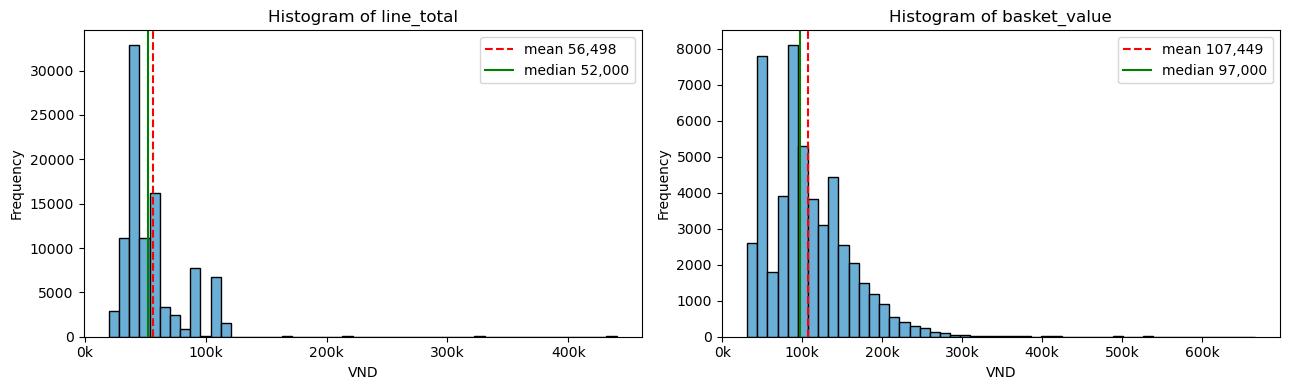

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, x, name in [(ax[0], clean["line_total"], "line_total"), (ax[1], basket, "basket_value")]:
    a.hist(x, bins=50, edgecolor="black", color="#6BAED6")
    a.axvline(x.mean(),   color="red",   ls="--", label=f"mean {x.mean():,.0f}")
    a.axvline(x.median(), color="green", ls="-",  label=f"median {x.median():,.0f}")
    a.set_title(f"Histogram of {name}"); a.set_xlabel("VND"); a.set_ylabel("Frequency")
    a.xaxis.set_major_formatter(money); a.legend()
plt.tight_layout(); plt.show()

## Task 3d — Boxplot

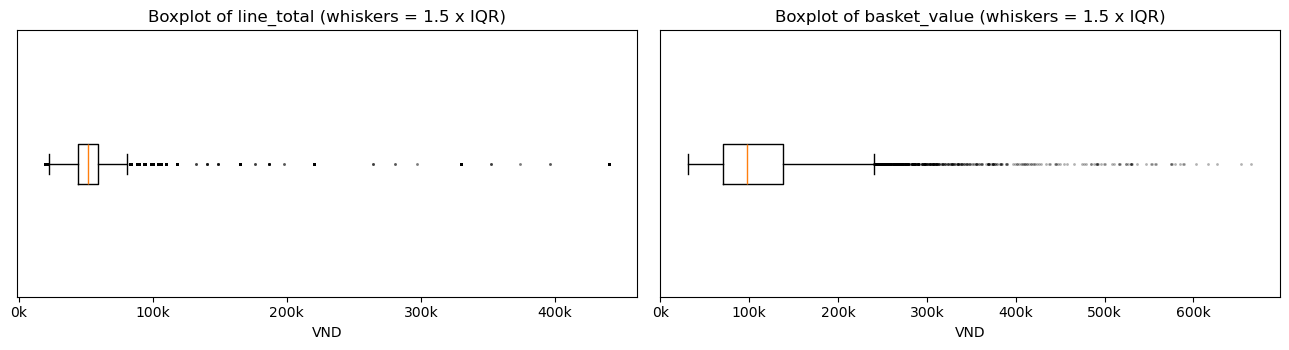

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, x, name in [(ax[0], clean["line_total"], "line_total"), (ax[1], basket, "basket_value")]:
    a.boxplot(x, vert=False, whis=1.5, flierprops=dict(marker=".", markersize=2, alpha=.3))
    a.set_title(f"Boxplot of {name} (whiskers = 1.5 x IQR)"); a.set_xlabel("VND")
    a.xaxis.set_major_formatter(money); a.set_yticks([])
plt.tight_layout(); plt.show()

## Task 3e — Scatter: seats against revenue (one point per store)

,store_id,store_name,store_type,seats,revenue,orders
0,1,Nguyen Hue,mall,70,760666575,6889
1,2,Ben Thanh,mall,62,711395700,6492
2,3,Landmark 81,mall,58,642014575,5881
3,4,Vincom Dong Khoi,mall,54,522155500,4818
4,5,Crescent Mall,mall,48,474655550,4327
5,6,Van Hanh Mall,mall,44,423011800,3845
6,7,University Village,campus,40,254741775,2481
7,8,RMIT Campus,campus,36,191046275,1853
8,9,Phu Nhuan Corner,residential,32,316615875,2895
9,10,Binh Thanh Garden,residential,30,297343925,2657


Pearson  r : 0.7218
Spearman rho: 0.6503


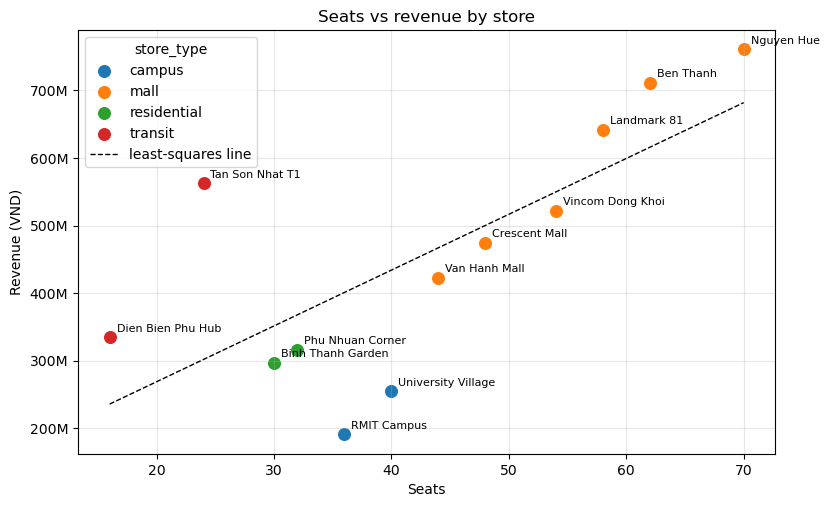

In [11]:
store_sum = (clean.groupby(["store_id", "store_name", "store_type", "seats"], as_index=False)
                  .agg(revenue=("line_total", "sum"), orders=("order_id", "nunique")))
display(store_sum)

print("Pearson  r :", round(store_sum["seats"].corr(store_sum["revenue"]), 4))
print("Spearman rho:", round(store_sum["seats"].corr(store_sum["revenue"], method="spearman"), 4))

slope, intercept = np.polyfit(store_sum["seats"], store_sum["revenue"], 1)
xs = np.linspace(store_sum["seats"].min(), store_sum["seats"].max(), 50)

plt.figure(figsize=(9, 5.5))
for t, g in store_sum.groupby("store_type"):
    plt.scatter(g["seats"], g["revenue"], s=70, label=t)
plt.plot(xs, intercept + slope * xs, "k--", lw=1, label="least-squares line")
for _, r in store_sum.iterrows():
    plt.annotate(r["store_name"], (r["seats"], r["revenue"]), fontsize=8, xytext=(5, 4), textcoords="offset points")
plt.title("Seats vs revenue by store"); plt.xlabel("Seats"); plt.ylabel("Revenue (VND)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1e6:,.0f}M"))
plt.legend(title="store_type"); plt.grid(alpha=.3); plt.show()

### Reading Task 3

* `line_total` and `basket_value` are **right-skewed**: the mean is above the median, skewness is positive and the long tail is on the right (multi-item and two-quantity orders).
  The median is the safer "typical" value; the mean is pulled up by large baskets.
* Once the five faults are repaired, the points beyond the 1.5 x IQR fences are genuine large purchases, not errors, so they are kept.
* Seats and revenue rise together (positive Pearson and Spearman), but the relationship is loose: stores with the same number of seats earn very different revenue, so seats alone do not explain revenue (see Practice 3.2).

## Task 4 — Practice 1 to Practice 4

### Practice 1.1 — Attribute type of every column (`saigon_bean_stores.csv`, `saigon_bean_products.csv`)

**saigon_bean_stores.csv**

| Column | Attribute type | Numeric column: discrete or continuous? |
|---|---|---|
| `store_id` | Nominal (identifier) | numeric code, **discrete**; the value is a label, not a quantity |
| `store_name` | Nominal | not numeric |
| `district` | Nominal | not numeric |
| `store_type` | Nominal (categories without a natural order) | not numeric |
| `seats` | Ratio (true zero, counts of chairs) | **discrete** (whole numbers) |

**saigon_bean_products.csv**

| Column | Attribute type | Numeric column: discrete or continuous? |
|---|---|---|
| `product_id` | Nominal (identifier) | numeric code, **discrete**; a label, not a quantity |
| `product_name` | Nominal | not numeric |
| `category` | Nominal | not numeric |
| `list_price` | Ratio (true zero, money in VND) | **continuous** (a measurement on a scale; it only happens to be recorded in whole dong) |

In [12]:
# Support for Practice 1.1: confirm the column names and pandas dtypes used in the table above
for name, t in [("stores", stores), ("products", products)]:
    print(name, "->", dict(t.dtypes.astype(str)))

stores -> {'store_id': 'int64', 'store_name': 'object', 'district': 'object', 'store_type': 'object', 'seats': 'int64'}
products -> {'product_id': 'int64', 'product_name': 'object', 'category': 'object', 'list_price': 'int64'}


### Practice 1.2 — The five faults: what I would do, and what doing nothing costs

1. **Duplicate rows (40 lines).** *Do:* delete exact copies and ask IT to stop the double export. *Cost of doing nothing:* some sales are counted twice, so revenue and order counts are overstated and the error can grow with every new load.
2. **Channel written in different ways (`In-Store`, `App`, `Delivery`, 30 lines).** *Do:* standardise to three labels and restrict the field to a drop-down list. *Cost:* reports show six "channels" and split app, delivery and in-store totals, so channel shares and channel targets are wrong.
3. **Negative quantities (25 lines).** *Do:* correct the sign, since there is no matching sale to reverse. *Cost:* revenue is understated, some baskets appear smaller than they are, and units sold per product are too low.
4. **Prices 100 times too large (12 lines).** *Do:* reset the price to the menu price and recompute the line total. *Cost:* twelve lines of millions of dong inflate revenue and ruin averages, so pricing and basket decisions would rest on numbers that no customer ever paid.
5. **Missing customer (about 35% of lines).** *Do:* keep the sales, add a "customer unknown" flag, and use only known customers for loyalty and repeat-purchase analysis. *Cost:* deleting them would remove a third of real revenue; ignoring the gap would make customer metrics look like they describe everyone when they describe only identified customers.

### Practice 1.3 — Mean of `store_id` = 6.5

The arithmetic is right because (1 + 2 + ... + 12) / 12 = 6.5, but `store_id` is a nominal label: the numbers only name the stores and could be re-issued in any order without changing anything about the business. The result therefore describes no store (there is no store 6.5) and measures nothing, and it would change if the IDs were renumbered.

### Practice 2.1 — Seats per store: mean, median, range, Q1, Q3, IQR and the 1.5 x IQR rule (by hand)

Sorted (n = 12): 16, 24, 30, 32, 36, 40, 44, 48, 54, 58, 62, 70

* **Mean** = (16+24+30+32+36+40+44+48+54+58+62+70) / 12 = 514 / 12 = **42.83**
* **Median** = average of the 6th and 7th values = (40 + 44) / 2 = **42**
* **Range** = 70 - 16 = **54**
* **Q1 and Q3, median-of-halves method:** lower half 16, 24, 30, 32, 36, 40 gives Q1 = (30 + 32) / 2 = **31**; upper half 44, 48, 54, 58, 62, 70 gives Q3 = (54 + 58) / 2 = **56**; **IQR** = 56 - 31 = **25**
* **Q1 and Q3, linear interpolation (pandas / numpy default):** position 1 + 0.25 x 11 = 3.75 gives Q1 = 30 + 0.75 x 2 = **31.5**; position 1 + 0.75 x 11 = 9.25 gives Q3 = 54 + 0.25 x 4 = **55**; **IQR** = **23.5**
* **1.5 x IQR rule:** 1.5 x 25 = 37.5, so the fences are 31 - 37.5 = -6.5 and 56 + 37.5 = 93.5. With the interpolation method the fences are 31.5 - 35.25 = -3.75 and 55 + 35.25 = 90.25.

**Conclusion:** the smallest store has 16 seats and the largest 70, both inside the fences under either method, so **no store is an outlier**.

In [13]:
# Support for Practice 2.1: check the hand calculation
seats = np.array([70, 62, 58, 54, 48, 44, 40, 36, 32, 30, 24, 16])
s = np.sort(seats); half = len(s) // 2
q1_h, q3_h = np.median(s[:half]), np.median(s[half:])                # median of halves
q1_i, q3_i = np.percentile(s, [25, 75])                              # linear interpolation
print("mean", round(seats.mean(), 2), "| median", np.median(seats), "| range", np.ptp(seats))
for name, a, b in [("median-of-halves", q1_h, q3_h), ("interpolation   ", q1_i, q3_i)]:
    i = b - a
    print(f"{name}: Q1={a}  Q3={b}  IQR={i}  fences=({a-1.5*i}, {b+1.5*i})  outliers={seats[(seats < a-1.5*i) | (seats > b+1.5*i)].tolist()}")
print("Same seats as the stores file:", sorted(stores['seats']) == sorted(seats.tolist()))

mean 42.83 | median 42.0 | range 54
median-of-halves: Q1=31.0  Q3=56.0  IQR=25.0  fences=(-6.5, 93.5)  outliers=[]
interpolation   : Q1=31.5  Q3=55.0  IQR=23.5  fences=(-3.75, 90.25)  outliers=[]
Same seats as the stores file: True


### Practice 2.2 — Mode = 45,000 dong, median = 97,000 dong

* **Mode, 45,000 dong:** the most frequent basket. It is the customer who buys one standard drink (a single item at the 45,000 dong price point). It describes the most common visit, the "grab a drink" customer.
* **Median, 97,000 dong:** the middle basket, with half of all baskets below it and half above. It describes the typical customer's spend across all order sizes, for example a drink plus a pastry or two drinks.
* **A decision that should use the mode:** deciding what to put at the fast counter and the entry price point, for instance the drink to feature in a 45,000 dong "quick order" promotion or to pre-prepare at peak hours, because the most common single purchase is the one that sets queue length and stock. (The median is the right number for revenue planning, such as revenue per order.)

### Practice 2.3 — Remove the twelve price-scale errors: which of mean, median, standard deviation, IQR changes?

**Justification before computing** (twelve lines out of about 97,000, each worth millions of dong instead of tens of thousands):

* **Standard deviation changes the most.** It squares each deviation, so twelve values that are 100 times too large contribute enormously; removing them should shrink the standard deviation to a fraction of its size (roughly a third of it).
* **Mean changes visibly.** It is a sum divided by n, so twelve millions-sized values move it, but only by about 1-2%, because they are diluted by tens of thousands of normal rows. It is the only location measure that moves.
* **Median barely moves.** It depends only on the rank order; twelve extreme rows sit at the very top and shift the middle position by at most six places out of ~97,000, so it stays essentially the same (often exactly the same).
* **IQR barely moves.** Q1 and Q3 are also rank-based, and the twelve rows are far beyond Q3, so removing them shifts the quartiles by a few positions at most.

The cell below computes the four numbers on the transaction file before and after removing those twelve rows.

In [14]:
# Support for Practice 2.3: the raw joined file, before and after dropping only the 12 price-scale rows
bad12 = df["unit_price"] > df["list_price"] * 10
print("Rows removed:", int(bad12.sum()))

def four(x):
    return pd.Series({"mean": x.mean(), "median": x.median(), "std": x.std(),
                      "IQR": x.quantile(.75) - x.quantile(.25)})

cmp = pd.DataFrame({"with 12 errors": four(df["line_total"]),
                    "without them":   four(df.loc[~bad12, "line_total"])})
cmp["change"]   = cmp["without them"] - cmp["with 12 errors"]
cmp["change %"] = 100 * cmp["change"] / cmp["with 12 errors"]
display(cmp.round(2))

Rows removed: 12


,with 12 errors,without them,change,change %
mean,57196.94,56467.06,-729.88,-1.28
median,52000.00,52000.00,0.00,0.00
std,78972.55,25460.08,-53512.47,-67.76
IQR,14800.00,14800.00,0.00,0.00


### Practice 3.1 — Quantile plot of the basket value (nine percentile values)

**How to sketch it by hand:** put the percentile (10, 20, ..., 90, or f-value 0.1 to 0.9) on the horizontal axis and the basket value in VND on the vertical axis; plot the nine percentile points and join them. Mark the **median** (P50) with a horizontal and vertical dotted line, and shade the vertical band between **Q1 (P25)** and **Q3 (P75)** as the interquartile range. The cell below draws the same figure from the data to check the sketch.

**Shape, one sentence:** the curve is flat and gentle over the lower percentiles and bends steeply upward in the top decile, which means most baskets are close together in value while a few very large baskets stretch the upper tail (right-skewed, mean above median).

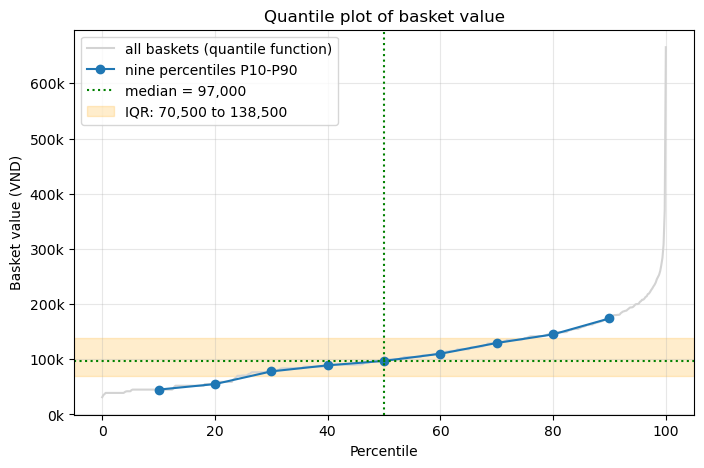

{'P10': np.float64(45000.0), 'P20': np.float64(55000.0), 'P30': np.float64(78000.0), 'P40': np.float64(89000.0), 'P50': np.float64(97000.0), 'P60': np.float64(110000.0), 'P70': np.float64(129500.0), 'P80': np.float64(145100.0), 'P90': np.float64(174000.0)}


In [15]:
# Support for Practice 3.1
ps = np.arange(10, 100, 10)
pv = np.percentile(basket, ps)
q1b, q2b, q3b = np.percentile(basket, [25, 50, 75])
f = np.linspace(0, 1, 501)
plt.figure(figsize=(8, 5))
plt.plot(f * 100, np.quantile(basket, f), color="lightgray", label="all baskets (quantile function)")
plt.plot(ps, pv, "o-", label="nine percentiles P10-P90")
plt.axhline(q2b, color="green", ls=":"); plt.axvline(50, color="green", ls=":", label=f"median = {q2b:,.0f}")
plt.axhspan(q1b, q3b, color="orange", alpha=.2, label=f"IQR: {q1b:,.0f} to {q3b:,.0f}")
plt.xlabel("Percentile"); plt.ylabel("Basket value (VND)"); plt.title("Quantile plot of basket value")
plt.gca().yaxis.set_major_formatter(money); plt.legend(); plt.grid(alpha=.3); plt.show()
print(dict(zip([f"P{p}" for p in ps], pv.round(0))))

### Practice 3.2 — "Adding seats raises revenue" from the scatter plot

**Two reasons the conclusion does not follow**

1. **Correlation is not causation.** The plot only shows that stores with more seats also have more revenue. Nobody added seats to a store and watched its revenue: big stores may sit in busy places (malls, the city centre) that produce both more space and more customers, so location and foot traffic can drive both variables.
2. **The relationship is loose and rests on twelve stores.** Stores with similar seats have very different revenue (the 24-seat Tan Son Nhat T1 earns more than the 44-seat Van Hanh Mall, while the 36-seat RMIT Campus earns far less than the 32-seat stores near it), so seats explain only part of revenue, and with n = 12 one or two unusual stores can change the line.

**One additional attribute to plot before answering:** `store_type` (and with it location), for example by colouring the points by store type; foot traffic or opening hours would also help, because they separate "more seats" from "better location".

In [16]:
# Support for Practice 3.2: revenue per seat and store type make the confounding visible
display(store_sum.assign(revenue_per_seat=(store_sum["revenue"] / store_sum["seats"]).round(0))
                 .sort_values("revenue_per_seat", ascending=False)
                 [["store_name", "store_type", "seats", "revenue", "revenue_per_seat"]])

,store_name,store_type,seats,revenue,revenue_per_seat
10,Tan Son Nhat T1,transit,24,562553225,23439718.0
11,Dien Bien Phu Hub,transit,16,335302750,20956422.0
1,Ben Thanh,mall,62,711395700,11474124.0
2,Landmark 81,mall,58,642014575,11069217.0
0,Nguyen Hue,mall,70,760666575,10866665.0
9,Binh Thanh Garden,residential,30,297343925,9911464.0
8,Phu Nhuan Corner,residential,32,316615875,9894246.0
4,Crescent Mall,mall,48,474655550,9888657.0
3,Vincom Dong Khoi,mall,54,522155500,9669546.0
5,Van Hanh Mall,mall,44,423011800,9613905.0


### Practice 3.3 — Better chart for each question

* **(a) Do the twelve stores differ in basket value?** Side-by-side **boxplots**, one per store: they put twelve distributions on one axis and show median, spread and outliers for each store, which a single histogram cannot do.
* **(b) Does the basket value have one peak or two?** A **histogram**: it shows the shape of the distribution and therefore the number of modes, which a boxplot hides.
* **(c) Is the basket value normally distributed?** A **normal Q-Q plot**: if the data are normal the points fall on a straight line, and the departures (curved tail, skew) are easy to read, unlike in a histogram.
* **(d) Which hour of the day is busiest?** A **bar chart** of the number of orders per hour: hours are discrete categories on a clock and the tallest bar answers the question directly.

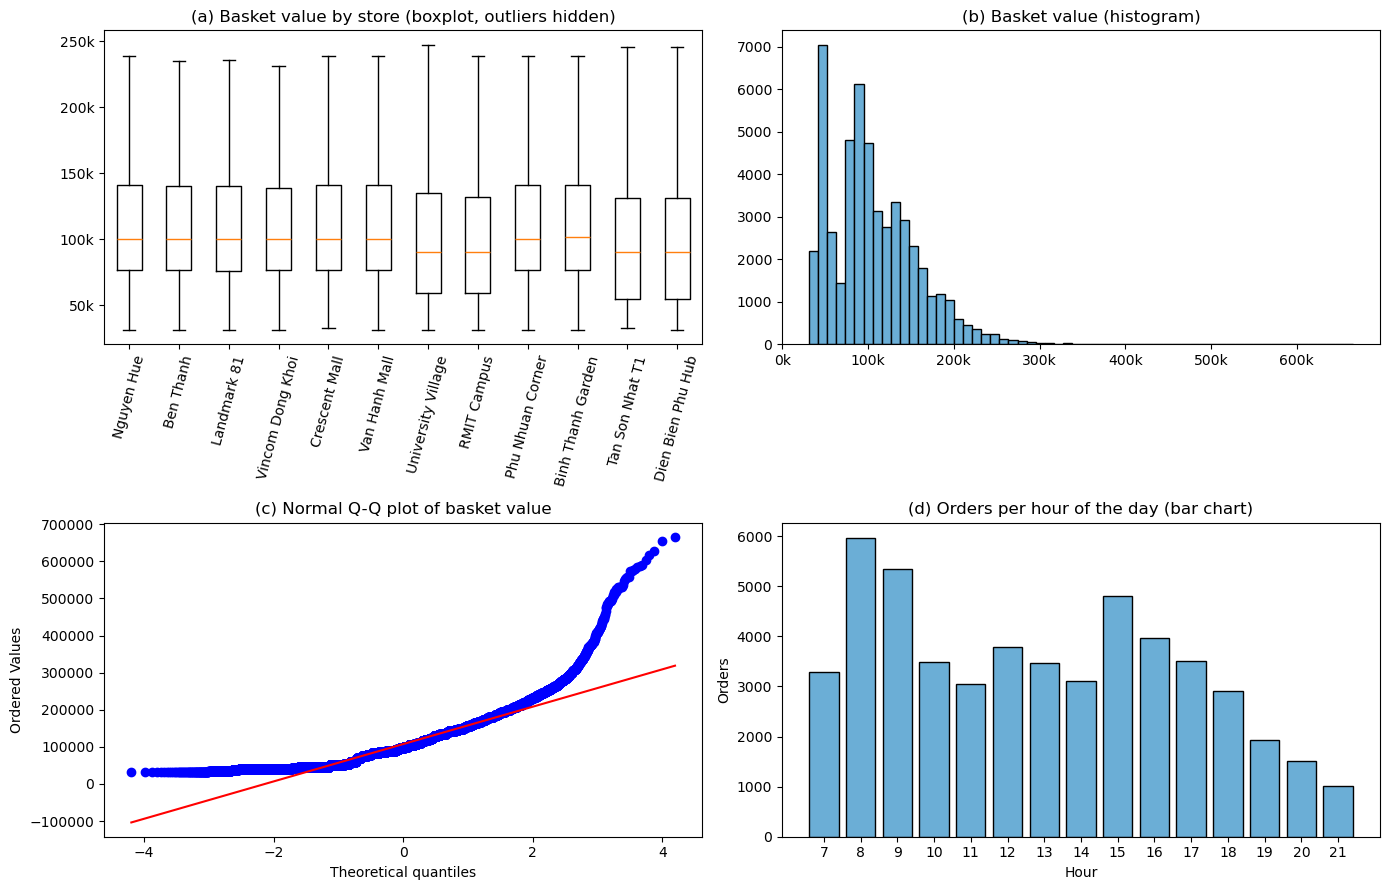

Busiest hour: 8 with 5970 orders


In [17]:
# Support for Practice 3.3: the four charts
orders = clean.drop_duplicates("order_id").copy()
orders["basket_value"] = orders["order_id"].map(basket)
orders["hour"] = orders["order_time"].dt.hour
by_hour = orders.groupby("hour").size()

fig, ax = plt.subplots(2, 2, figsize=(14, 9))

names = stores.set_index("store_id")["store_name"]
order_ids = sorted(orders["store_id"].unique())
ax[0, 0].boxplot([orders.loc[orders["store_id"] == i, "basket_value"] for i in order_ids],
                 whis=1.5, showfliers=False)
ax[0, 0].set_xticks(range(1, len(order_ids) + 1)); ax[0, 0].set_xticklabels([names[i] for i in order_ids])
ax[0, 0].set_title("(a) Basket value by store (boxplot, outliers hidden)")
ax[0, 0].tick_params(axis="x", rotation=75); ax[0, 0].yaxis.set_major_formatter(money)

ax[0, 1].hist(orders["basket_value"], bins=60, edgecolor="black", color="#6BAED6")
ax[0, 1].set_title("(b) Basket value (histogram)"); ax[0, 1].xaxis.set_major_formatter(money)

st.probplot(orders["basket_value"], dist="norm", plot=ax[1, 0])
ax[1, 0].set_title("(c) Normal Q-Q plot of basket value")

ax[1, 1].bar(by_hour.index, by_hour.values, color="#6BAED6", edgecolor="black")
ax[1, 1].set_title("(d) Orders per hour of the day (bar chart)"); ax[1, 1].set_xlabel("Hour"); ax[1, 1].set_ylabel("Orders")
ax[1, 1].set_xticks(by_hour.index)

plt.tight_layout(); plt.show()
print("Busiest hour:", int(by_hour.idxmax()), "with", int(by_hour.max()), "orders")

### Practice 4.1 — Ben Thanh vs Binh Thanh Garden on the channel-share vector

Vectors (in-store %, app %, delivery %): Ben Thanh (61.6, 22.5, 15.9) and Binh Thanh Garden (43.1, 36.8, 20.0). The differences are 18.5, 14.3 and 4.1.

* **Manhattan** = 18.5 + 14.3 + 4.1 = **36.9** (percentage points)
* **Euclidean** = sqrt(18.5^2 + 14.3^2 + 4.1^2) = sqrt(342.25 + 204.49 + 16.81) = sqrt(563.55) = **23.74**

**Which to report to a manager: Manhattan.** It is in a unit a manager understands (percentage points of the channel mix) and adds the gaps directly: about half of 36.9, roughly 18 to 19% of the orders, would have to move to another channel to make the two stores look alike. The Euclidean value squares the gaps, so it emphasises the biggest gap and has no everyday meaning.

In [18]:
# Support for Practice 4.1
bt  = np.array([61.6, 22.5, 15.9])
btg = np.array([43.1, 36.8, 20.0])
print("Manhattan:", round(np.abs(bt - btg).sum(), 2), "| Euclidean:", round(np.sqrt(((bt - btg) ** 2).sum()), 2))

Manhattan: 36.9 | Euclidean: 23.74


### Practice 4.2 — Jaccard similarity of two customers

A = {101, 102, 301}, B = {101, 105, 301, 302}.

* Intersection = {101, 301}, so 2 items; union = {101, 102, 105, 301, 302}, so 5 items.
* **Jaccard = 2 / 5 = 0.40**

**Why the symmetric binary measure misleads:** with 17 products in the catalogue, 12 of them are bought by neither customer, and the symmetric measure counts each of those shared absences as agreement, giving (2 + 12) / 17 = 0.82 for two customers who have only 2 of 5 purchased items in common.

In [19]:
# Support for Practice 4.2
A, B = {101, 102, 301}, {101, 105, 301, 302}
n_products = len(products)
both, either = len(A & B), len(A | B)
print("Jaccard:", both, "/", either, "=", both / either)
print("Symmetric matching:", (both + (n_products - either)), "/", n_products, "=", round((both + n_products - either) / n_products, 3))

Jaccard: 2 / 5 = 0.4
Symmetric matching: 14 / 17 = 0.824


### Practice 4.3 — Clustering the twelve stores on seats alone

**Strongest objection:** seats measure only the size of the shop, not how it trades, so a one-attribute clustering just cuts the seat numbers into three intervals and ignores every other feature that defines a store's behaviour. The data show the damage: University Village (40 seats) sits right next to Van Hanh Mall (44 seats) on seats alone, yet 53% of its orders come through the app against 22% for Van Hanh Mall, a channel-mix distance of about 0.40, while the central malls with very different seat numbers (44 to 70) are almost identical in mix (distances below 0.02). The segments would therefore not correspond to how customers actually buy. (Slide 40 is not visible to me, so this argument rests on the data and on the general rule that the attributes must reflect the question and be put on a comparable scale.)

**Two attributes I would add:** the **channel-share vector** (in-store, app, delivery shares), and **`store_type`** (or, alternatively, average basket value); with more than one numeric attribute I would first standardise them so that no attribute dominates by units.

## Task 5 — 12 x 12 dissimilarity matrix of the stores on the channel-share vector

The vector of a store is its share of orders in (in-store, app, delivery), the same order as in Practice 4.1. The dissimilarity is the Euclidean distance between two such vectors (0 = identical mix).

Channel-share vectors (rows sum to 1):


channel,in-store,app,delivery
store_name,,,
Nguyen Hue,0.615,0.223,0.162
Ben Thanh,0.616,0.225,0.159
Landmark 81,0.622,0.221,0.157
Vincom Dong Khoi,0.624,0.215,0.161
Crescent Mall,0.623,0.220,0.156
Van Hanh Mall,0.620,0.220,0.161
University Village,0.372,0.534,0.094
RMIT Campus,0.368,0.539,0.093
Phu Nhuan Corner,0.459,0.345,0.195


Check against Practice 4.1 (percent): [61.6, 22.5, 15.9] [43.1, 36.8, 20.0]

Shape: (12, 12) | symmetric: True | zero diagonal: True


store_name,Nguyen Hue,Ben Thanh,Landmark 81,Vincom Dong Khoi,Crescent Mall,Van Hanh Mall,University Village,RMIT Campus,Phu Nhuan Corner,Binh Thanh Garden,Tan Son Nhat T1,Dien Bien Phu Hub
store_name,,,,,,,,,,,,
Nguyen Hue,0.000,0.004,0.009,0.012,0.011,0.006,0.400,0.407,0.201,0.237,0.372,0.390
Ben Thanh,0.004,0.000,0.007,0.012,0.009,0.006,0.399,0.406,0.201,0.238,0.370,0.389
Landmark 81,0.009,0.007,0.000,0.007,0.002,0.004,0.405,0.411,0.208,0.244,0.364,0.382
Vincom Dong Khoi,0.012,0.012,0.007,0.000,0.007,0.006,0.411,0.418,0.212,0.249,0.361,0.379
Crescent Mall,0.011,0.009,0.002,0.007,0.000,0.006,0.406,0.413,0.210,0.246,0.362,0.380
Van Hanh Mall,0.006,0.006,0.004,0.006,0.006,0.000,0.406,0.412,0.207,0.243,0.366,0.384
University Village,0.400,0.399,0.405,0.411,0.406,0.406,0.000,0.006,0.231,0.205,0.726,0.745
RMIT Campus,0.407,0.406,0.411,0.418,0.413,0.412,0.006,0.000,0.237,0.211,0.733,0.751
Phu Nhuan Corner,0.201,0.201,0.208,0.212,0.210,0.207,0.231,0.237,0.000,0.037,0.568,0.586


CLOSEST pair : Landmark 81 & Crescent Mall | distance = 0.002
FURTHEST pair: RMIT Campus & Dien Bien Phu Hub | distance = 0.7507

Five closest pairs:


,store_A,store_B,distance
0,Landmark 81,Crescent Mall,0.0020
1,Nguyen Hue,Ben Thanh,0.0039
2,Landmark 81,Van Hanh Mall,0.0044
3,Vincom Dong Khoi,Van Hanh Mall,0.0057
4,Crescent Mall,Van Hanh Mall,0.0058


Five furthest pairs:


,store_A,store_B,distance
65,RMIT Campus,Dien Bien Phu Hub,0.7507
64,University Village,Dien Bien Phu Hub,0.7446
63,RMIT Campus,Tan Son Nhat T1,0.7325
62,University Village,Tan Son Nhat T1,0.7264
61,Binh Thanh Garden,Dien Bien Phu Hub,0.6219


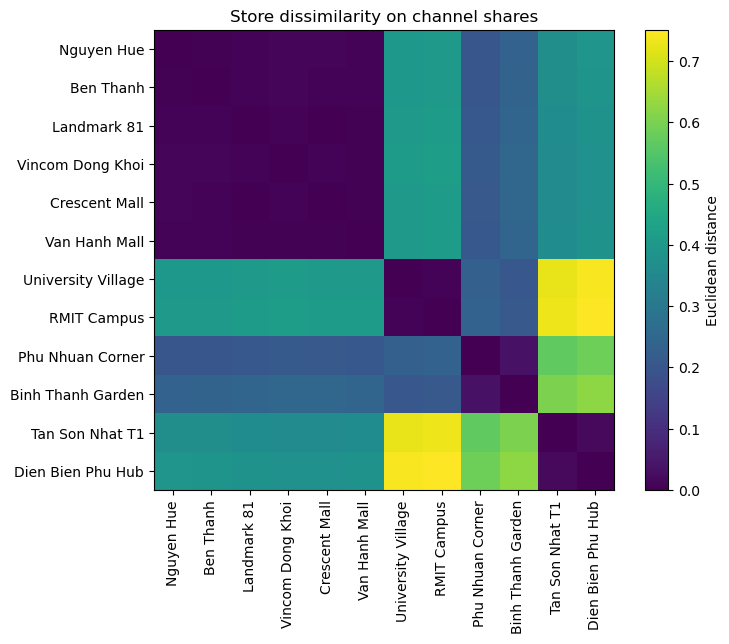

In [20]:
orders = clean.drop_duplicates("order_id")                 # one row per order, so shares count orders
share = orders.groupby(["store_id", "channel"]).size().unstack(fill_value=0)
share = share[["in-store", "app", "delivery"]]
share = share.div(share.sum(axis=1), axis=0)
share.index = stores.set_index("store_id").loc[share.index, "store_name"]
print("Channel-share vectors (rows sum to 1):")
display(share.round(3))
print("Check against Practice 4.1 (percent):",
      (share.loc["Ben Thanh"] * 100).round(1).tolist(), (share.loc["Binh Thanh Garden"] * 100).round(1).tolist())

# 12 x 12 Euclidean dissimilarity matrix
D = pd.DataFrame(squareform(pdist(share.values, metric="euclidean")), index=share.index, columns=share.index)
print("\nShape:", D.shape, "| symmetric:", np.allclose(D, D.T), "| zero diagonal:", np.allclose(np.diag(D), 0))
display(D.round(3))

# closest and furthest pairs (upper triangle only, no diagonal)
i, j = np.triu_indices(len(D), k=1)
pairs = (pd.DataFrame({"store_A": D.index[i], "store_B": D.columns[j], "distance": D.values[i, j]})
           .sort_values("distance").reset_index(drop=True))
print("CLOSEST pair :", pairs.iloc[0]["store_A"], "&", pairs.iloc[0]["store_B"], "| distance =", round(pairs.iloc[0]["distance"], 4))
print("FURTHEST pair:", pairs.iloc[-1]["store_A"], "&", pairs.iloc[-1]["store_B"], "| distance =", round(pairs.iloc[-1]["distance"], 4))
print("\nFive closest pairs:");  display(pairs.head(5).round(4))
print("Five furthest pairs:"); display(pairs.tail(5).iloc[::-1].round(4))

# heat map of the matrix
plt.figure(figsize=(8, 6.5))
plt.imshow(D.values, cmap="viridis"); plt.colorbar(label="Euclidean distance")
plt.xticks(range(12), D.columns, rotation=90); plt.yticks(range(12), D.index)
plt.title("Store dissimilarity on channel shares"); plt.tight_layout(); plt.show()

### Result of Task 5

* **Closest pair:** Landmark 81 and Crescent Mall (distance about 0.002), two central malls with almost the same channel mix.
* **Furthest pair:** RMIT Campus and Dien Bien Phu Hub (distance about 0.75): RMIT Campus is app-heavy (about 54% of orders through the app), while Dien Bien Phu Hub is almost all in-store (about 93%).
* **Structure of the matrix:** six central malls (Nguyen Hue, Ben Thanh, Landmark 81, Vincom Dong Khoi, Crescent Mall, Van Hanh Mall) form one tight group (in-store about 62%); University Village and RMIT Campus form an app-heavy pair; Tan Son Nhat T1 and Dien Bien Phu Hub form an in-store-dominant pair (above 90%); Phu Nhuan Corner and Binh Thanh Garden sit between the groups with a mixed channel profile.